In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [121]:
df = pd.read_csv("sales_data.csv", parse_dates=["Date"])

What's the mean of Customers_Age?

In [89]:
df["Customer_Age"].mean()

np.float64(35.91921157861212)

<Axes: ylabel='Density'>

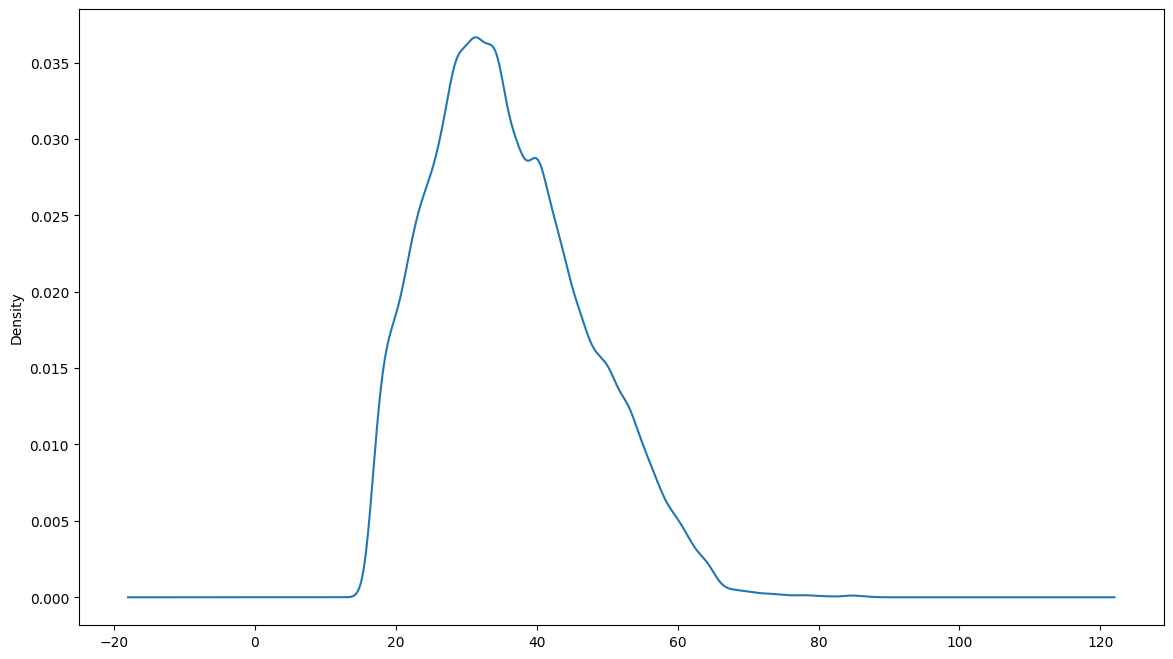

In [90]:
df["Customer_Age"].plot(kind="kde", figsize=(14,8))

Customer Age Box plot

<Axes: >

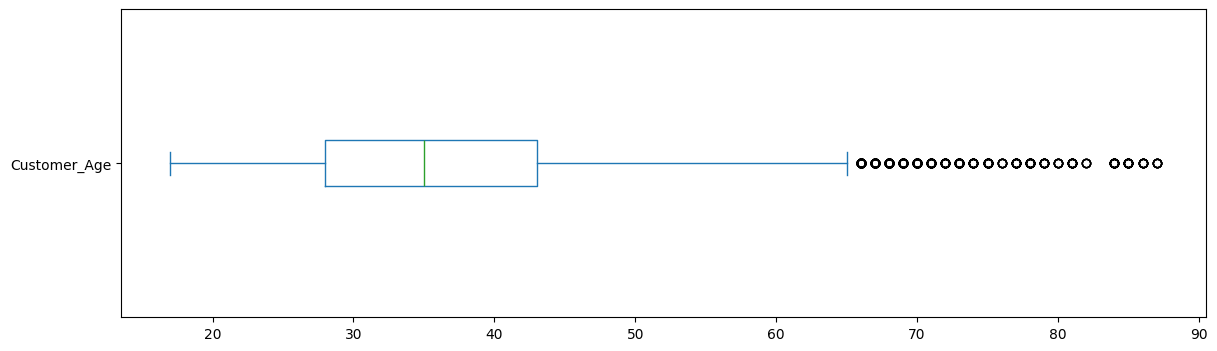

In [91]:
df["Customer_Age"].plot(kind="box", vert=False, figsize=(14,4))

What's the mean of Order_Quantity?

In [92]:
df["Order_Quantity"].mean()

np.float64(11.901659648253654)

Average Order_Quantity using histogram

<Axes: ylabel='Frequency'>

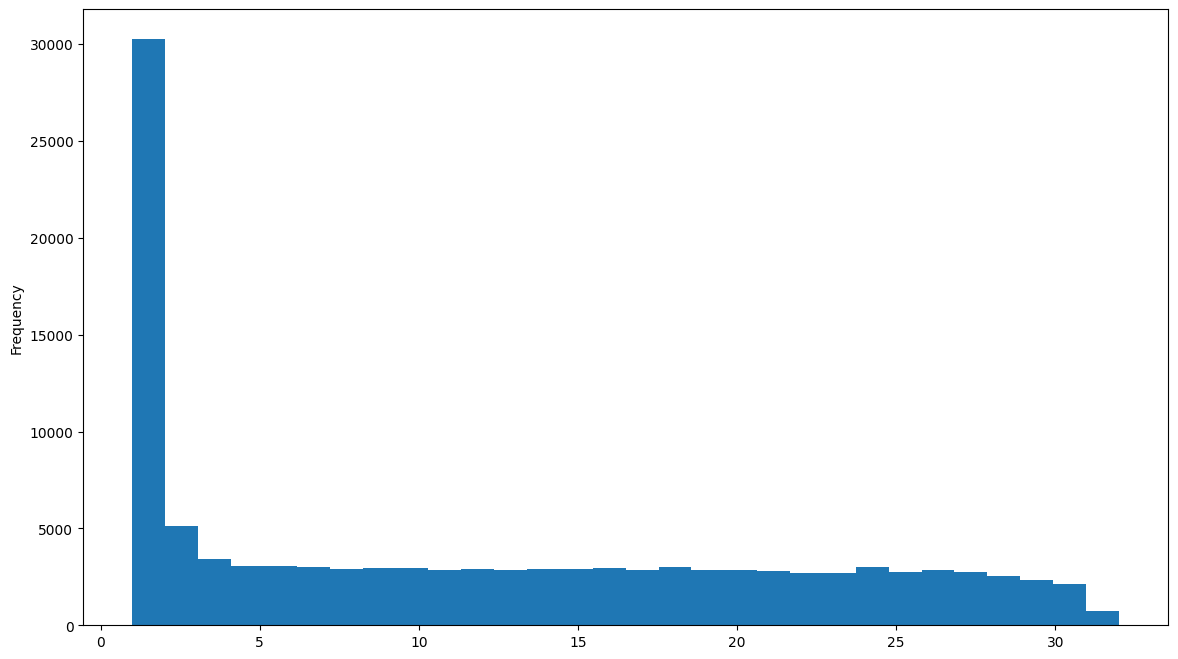

In [93]:
df["Order_Quantity"].plot(kind="hist",  bins=30, figsize=(14,8))

Order Quanity Box plot

<Axes: >

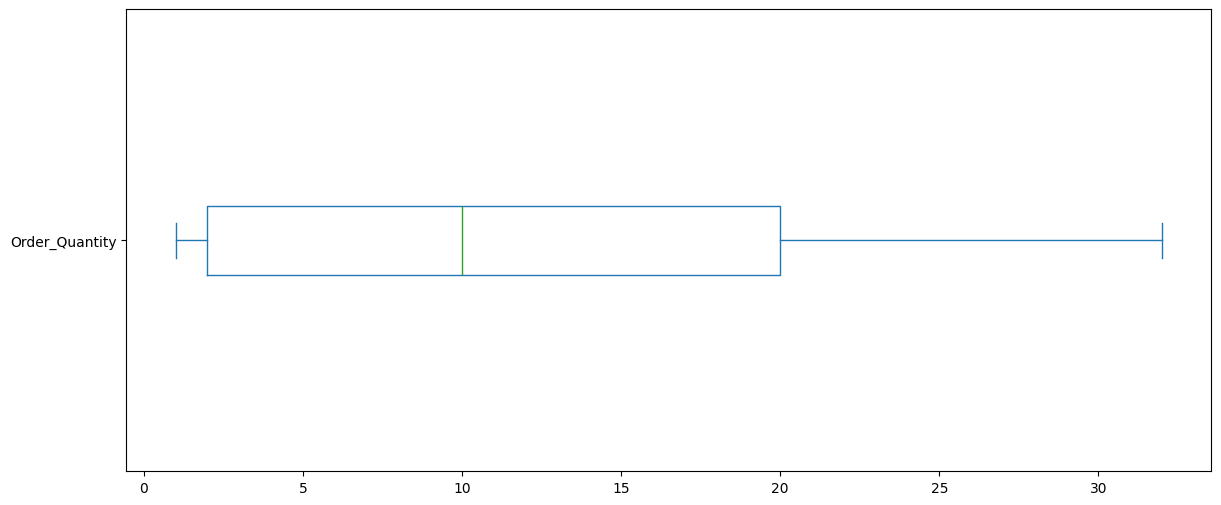

In [94]:
df["Order_Quantity"].plot(kind="box", vert = False, figsize=(14,6))

Number of products sold by year

In [95]:
df['Year'].value_counts()

Year
2014    29398
2016    29398
2013    24443
2015    24443
2012     2677
2011     2677
Name: count, dtype: int64

Percenage of Yearly Sold products

<Axes: >

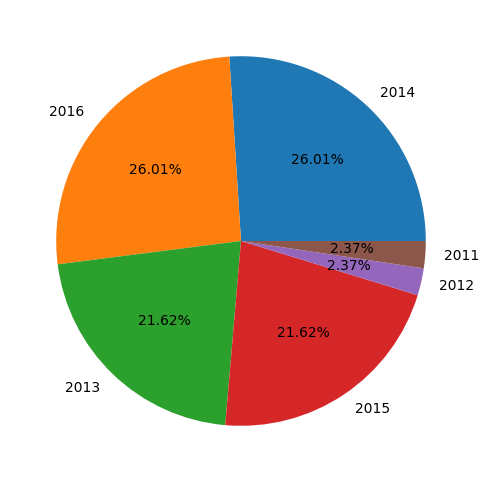

In [96]:
df['Year'].value_counts().plot(kind="pie", figsize=(6,6), autopct="%1.2f%%")


Number of monthly products sold

In [97]:
df["Month"].value_counts()

Month
June         11234
December     11200
May          11128
April        10182
March         9674
January       9284
February      9022
October       8750
November      8734
August        8200
September     8166
July          7462
Name: count, dtype: int64

Barchart of monthly products sold

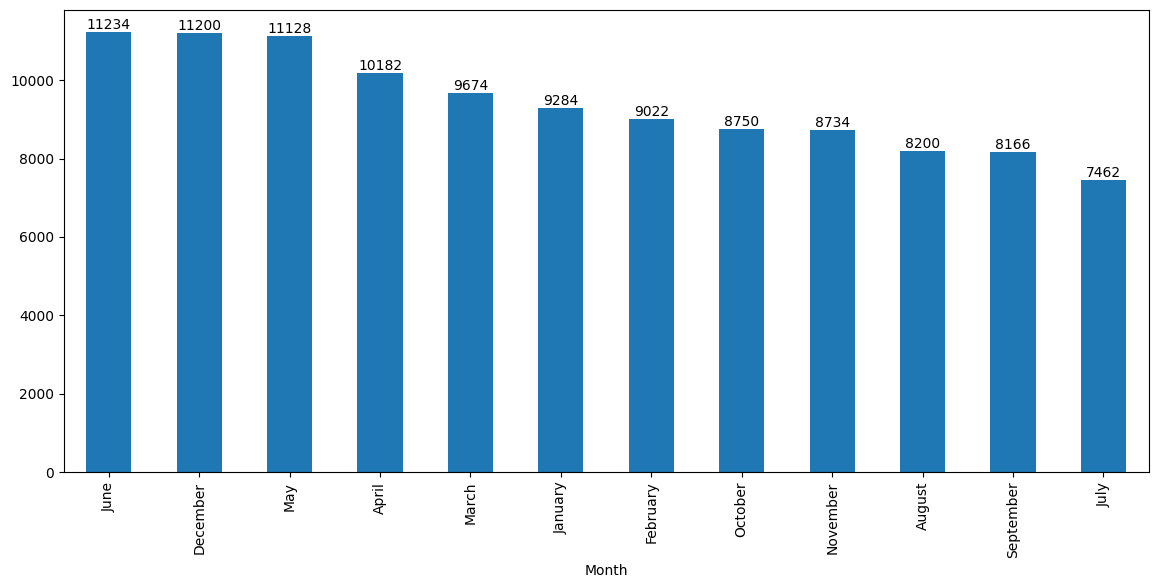

In [98]:
ax = df['Month'].value_counts().plot(kind="bar", figsize=(14, 6))

for label in ax.containers:
    ax.bar_label(label)


Top 1 country where the mostly product sold

In [99]:
df["Country"].value_counts().head(1)

Country
United States    39206
Name: count, dtype: int64

countries barchart where products solds

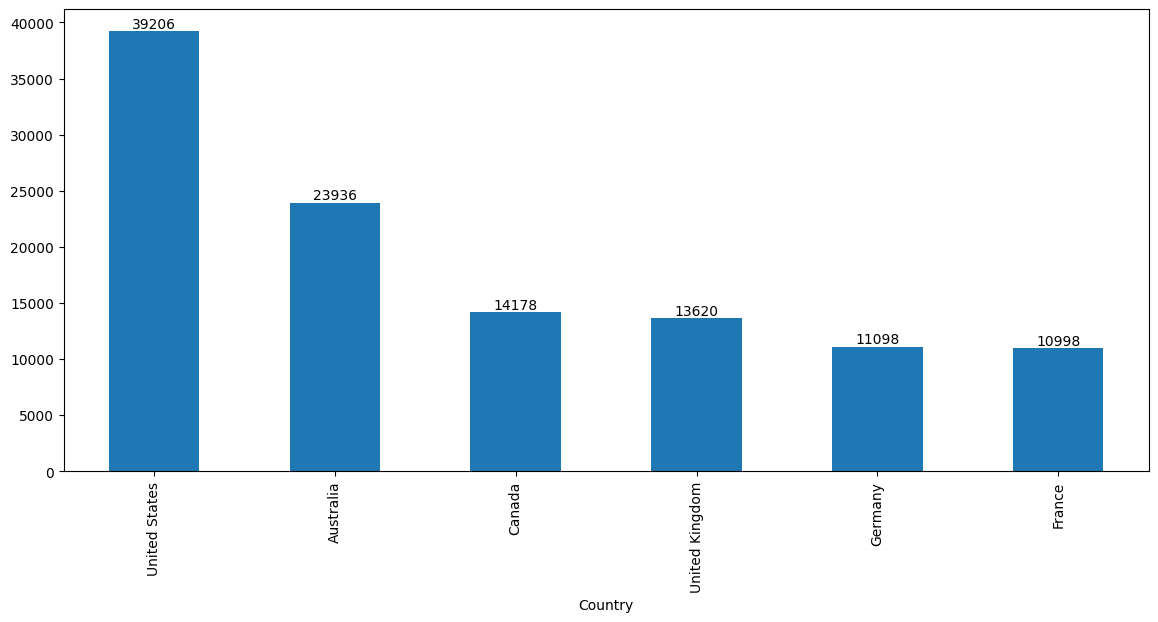

In [100]:
ax = df["Country"].value_counts().plot(kind="bar", figsize=(14, 6))

for i in ax.containers:
    ax.bar_label(i)

Identifing Unique products 

In [101]:
df["Product"].unique

<bound method Series.unique of 0         Hitch Rack - 4-Bike
1         Hitch Rack - 4-Bike
2         Hitch Rack - 4-Bike
3         Hitch Rack - 4-Bike
4         Hitch Rack - 4-Bike
                 ...         
113031        Classic Vest, S
113032        Classic Vest, M
113033        Classic Vest, M
113034        Classic Vest, L
113035        Classic Vest, L
Name: Product, Length: 113036, dtype: str>

Top 10 product sales 

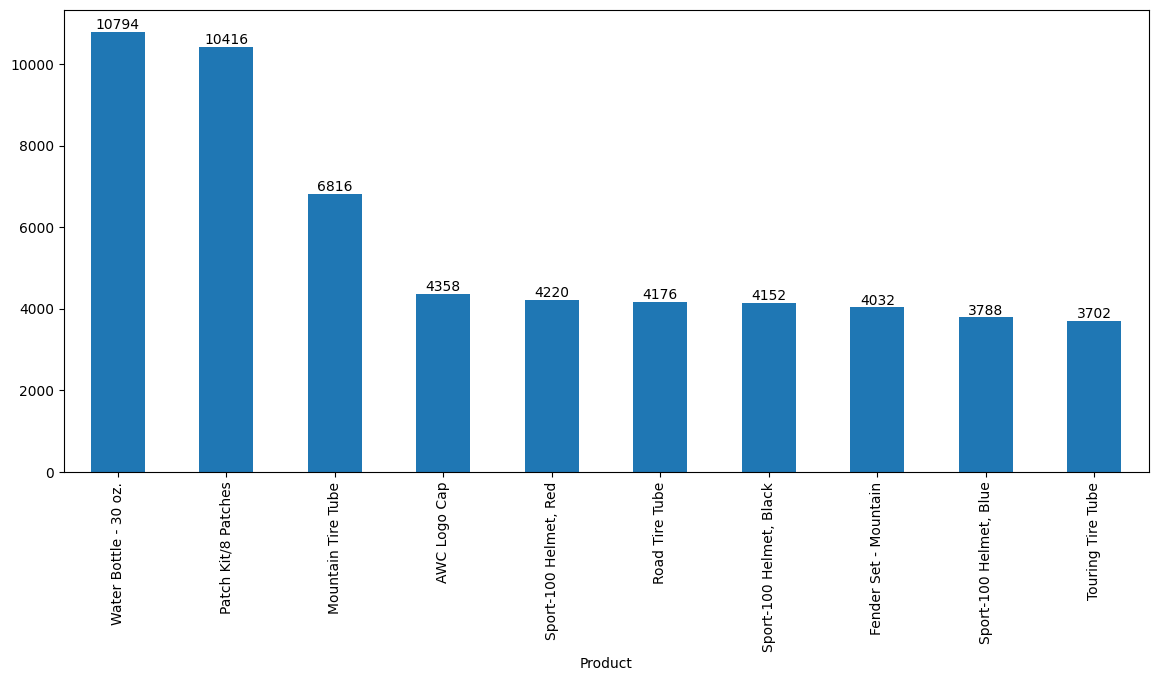

In [102]:
ax = df["Product"].value_counts().head(10).plot(kind="bar", figsize=(14,6))

for label in ax.containers:
    ax.bar_label(label)


Top 10 states where most products sold

Text(0.5, 1.0, 'Top 10 State')

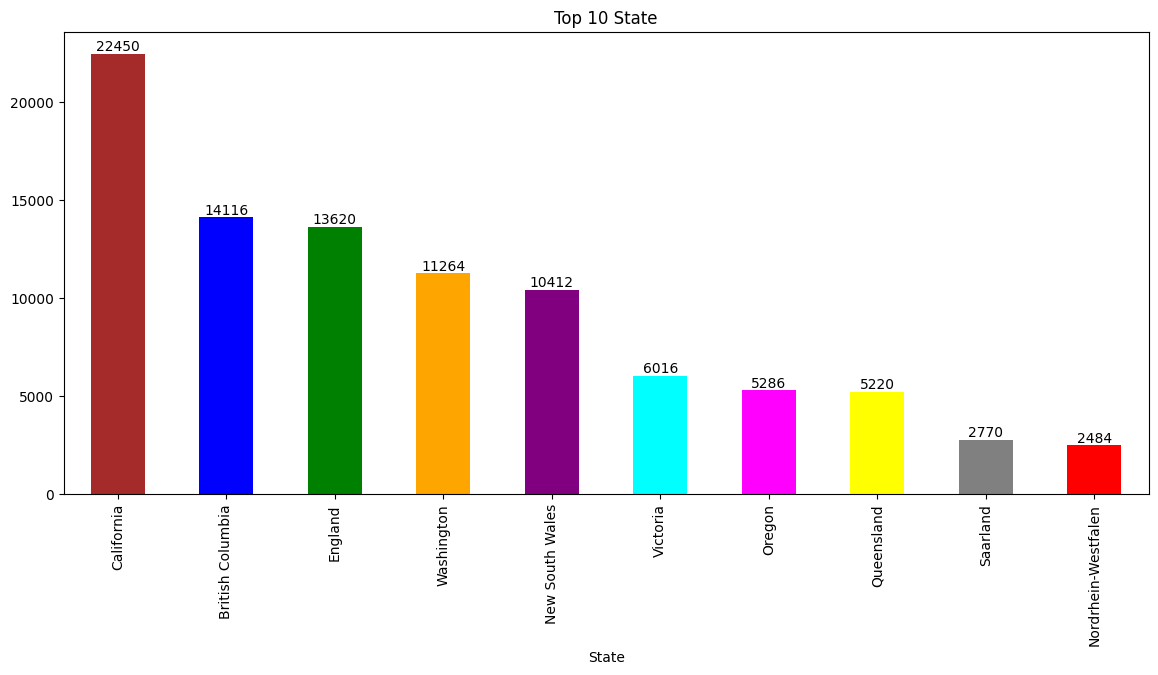

In [103]:
colors = [
    "brown", "blue", "green", "orange", "purple",
    "cyan", "magenta", "yellow", "gray", "red"
]
ax = df["State"].value_counts().head(10).plot(kind="bar", figsize=(14, 6), color=colors)

for i in ax.containers:
    ax.bar_label(i)

ax.set_title("Top 10 State")

Identifiying Unite_cost and Unit_price

<Axes: xlabel='Unit_Cost', ylabel='Unit_Price'>

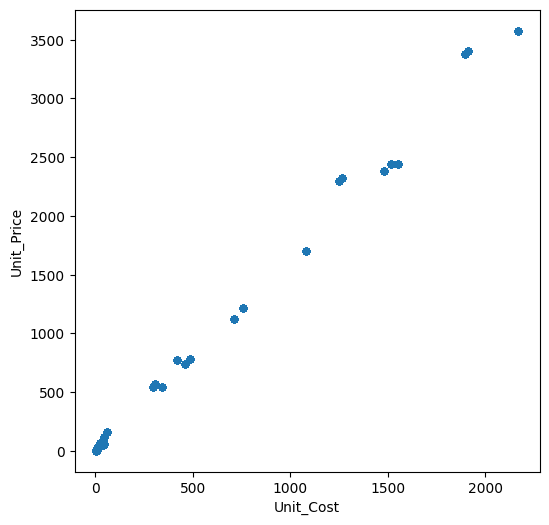

In [104]:
df.plot(kind="scatter", x="Unit_Cost", y="Unit_Price", figsize=(6,6))

Identifying relationship between order_quantity and profits

<Axes: xlabel='Order_Quantity', ylabel='Profit'>

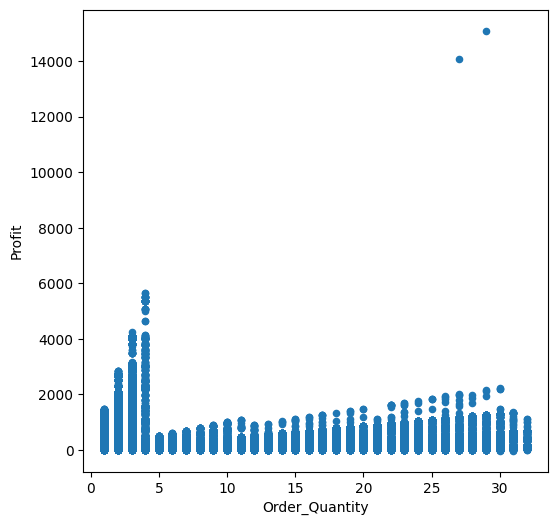

In [105]:
df.plot(kind="scatter", x="Order_Quantity", y="Profit", figsize=(6,6))

Relationship between profit and countries

<Axes: xlabel='Profit', ylabel='Country'>

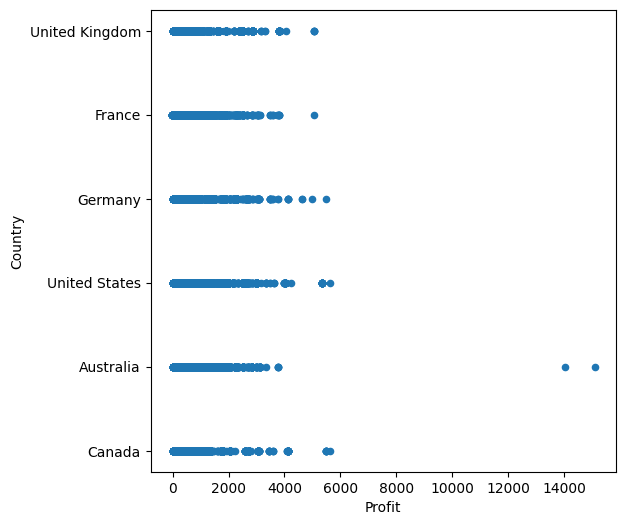

In [106]:
df.plot(kind="scatter", x="Profit", y="Country", figsize=(6,6))

Relationship of countries and profits using boxplot

<Axes: title={'center': 'Profit'}, xlabel='[Country]'>

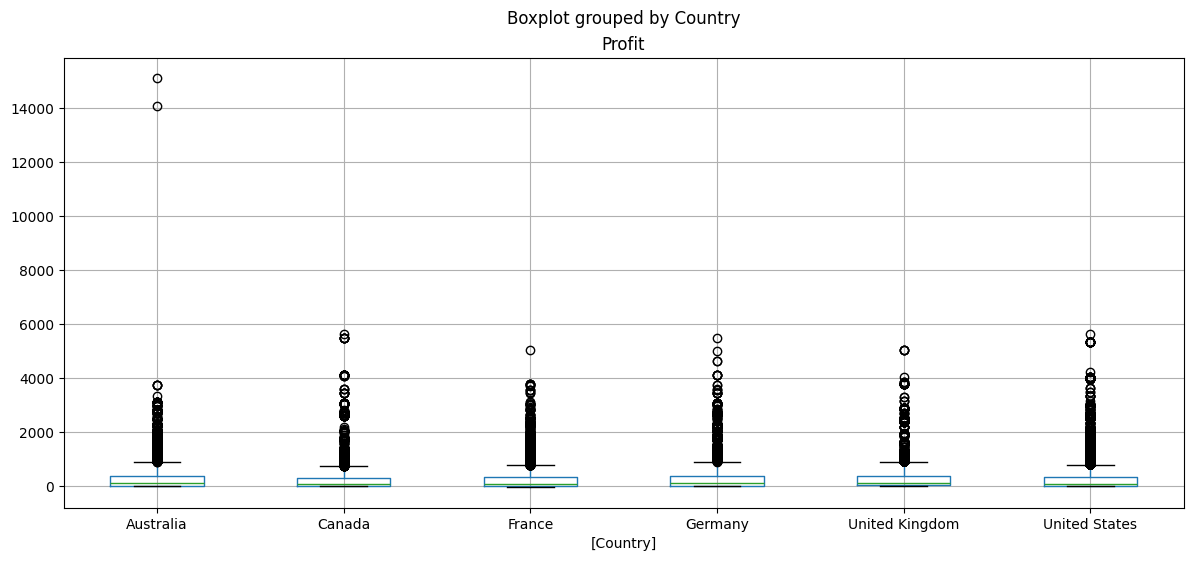

In [107]:
df[["Profit", "Country"]].boxplot(by="Country", figsize=(14,6))

Identifying which Age Category bought the product the most

<Axes: title={'center': 'Customer_Age'}, xlabel='[Country]'>

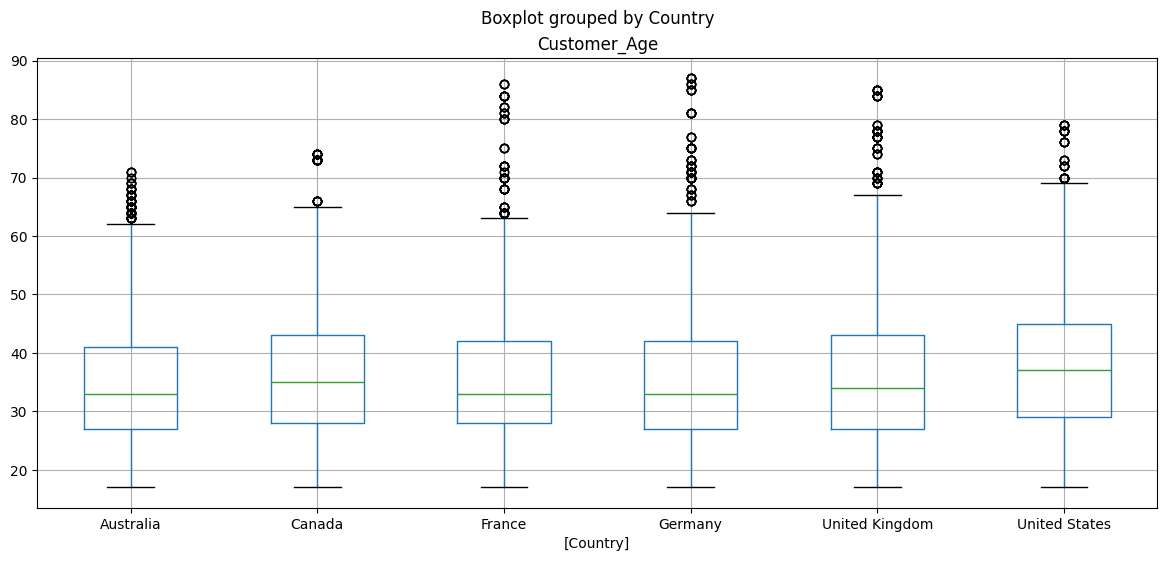

In [108]:
df[["Customer_Age", "Country"]].boxplot(by="Country", figsize=(14, 6))

<Axes: title={'center': 'Customer_Age'}, xlabel='[Country]'>

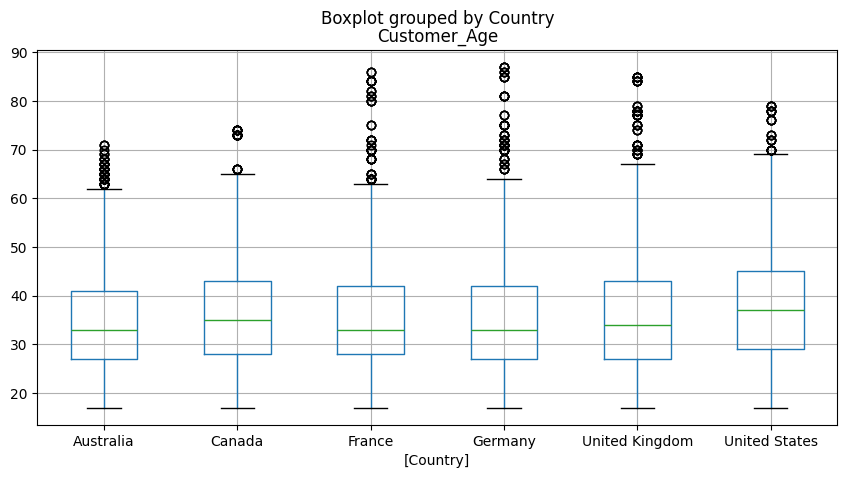

In [109]:
df[["Customer_Age", "Country"]].boxplot(by="Country", figsize=(10,5))

In [110]:
df["Month"] = pd.to_datetime(
    df["Month"],
    format="mixed"
).dt.month

df["Calculated_Date"] = pd.to_datetime(df[["Year", "Month", "Day"]])


green-divider
How did sales evolve through the years?

<Axes: xlabel='Calculated_Date'>

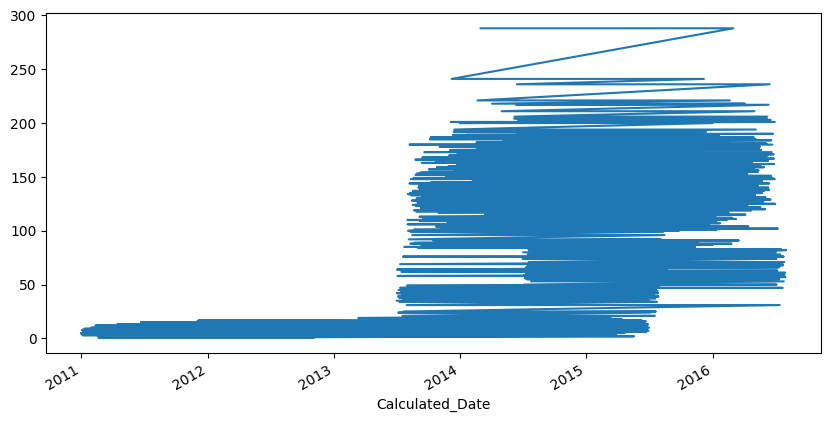

In [111]:
df["Calculated_Date"].value_counts().plot(kind='line', figsize=(10,5))

Yearly Revenue

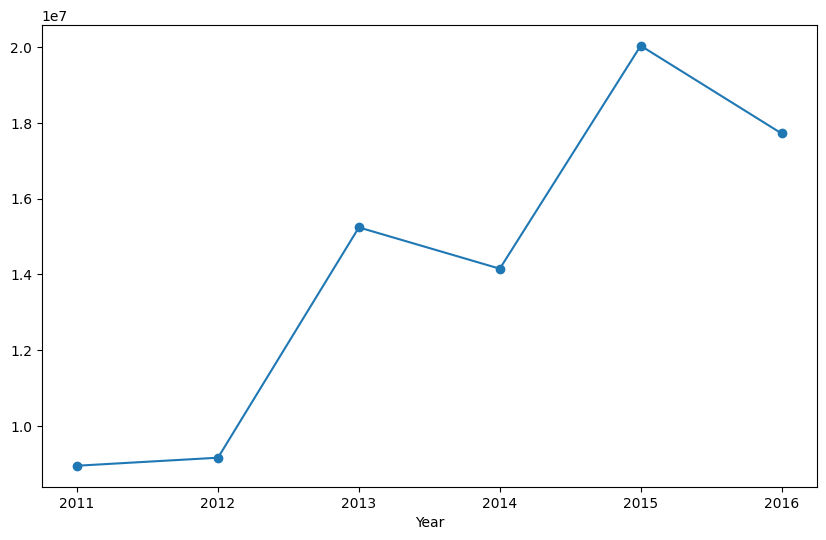

In [112]:
yearly_sales = df.groupby("Year")["Revenue"].sum()

ax = yearly_sales.plot(kind="line", figsize=(10,6), marker="o")

Monthly Revenue using pivot Table

<Axes: xlabel='Month'>

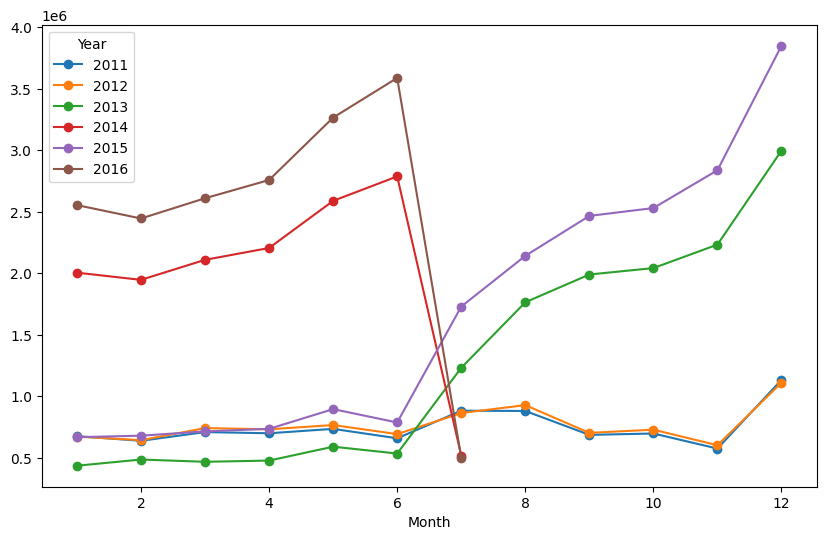

In [113]:
pivote_sales = df.pivot_table(
    index="Month",
    columns="Year",
    values="Revenue",
    aggfunc="sum"

)

pivote_sales.plot(kind="line", figsize=(10, 6), marker="o")

green-divider
How many orders were made in Canada or France?

In [114]:


df.loc[(df["Country"] == "Canada") | (df["Country"] == "France")].shape[0]

25176

In [115]:
df["Country"].value_counts()

Country
United States     39206
Australia         23936
Canada            14178
United Kingdom    13620
Germany           11098
France            10998
Name: count, dtype: int64

Revenue by Country

In [116]:
df.groupby("Country")['Revenue'].sum().sort_values(ascending=False)

Country
United States     27975547
Australia         21302059
United Kingdom    10646196
Germany            8978596
France             8432872
Canada             7935738
Name: Revenue, dtype: int64

Number of Bike Racks has been sold in Canada

In [117]:
df.loc[(df["Country"] == "Canada") | (df['Sub_Category'] == "Bike Racks")].shape[0]

14666

How many orders were made in each region (state) of France?

In [118]:
df.loc[df["Country"] == "France", "State"].value_counts()

State
Seine (Paris)        2328
Seine Saint Denis    1684
Nord                 1670
Hauts de Seine       1084
Essonne               994
Yveline               954
Seine et Marne        394
Moselle               386
Loiret                382
Val d'Oise            264
Garonne (Haute)       208
Val de Marne          158
Charente-Maritime     148
Somme                 134
Loir et Cher          120
Pas de Calais          90
Name: count, dtype: int64

<Axes: xlabel='State'>

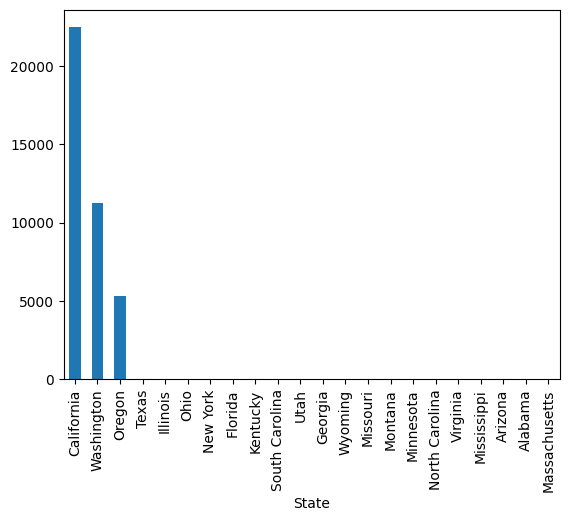

In [122]:
df.loc[df["Country"] == "United States", "State"].value_counts().plot(kind="bar")

How much Revenue mad in Canada disaggregation by its states

In [132]:
canada_Revenue = df.loc[df["Country"] == "Canada"].groupby("State")["Revenue"].sum().sort_values(ascending=False)

canada_Revenue

State
British Columbia    7877890
Alberta               56803
Ontario                1045
Name: Revenue, dtype: int64

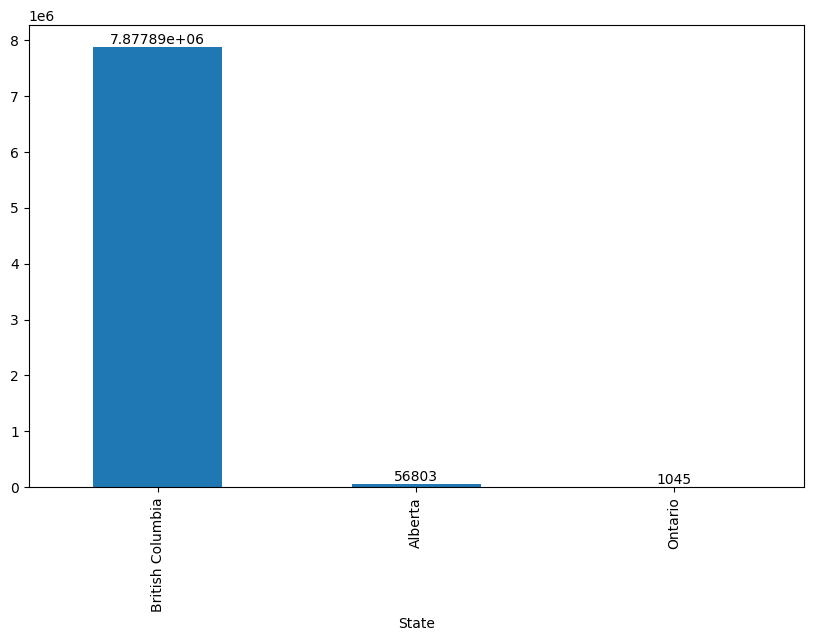

In [134]:
ax = canada_Revenue.plot(kind="bar", figsize=(10,6))

for container in ax.containers:
    ax.bar_label(container)

Germany States Revenue

In [138]:
germany_revenue = df.loc[df["Country"] == "Germany"].groupby("State")["Revenue"].sum().sort_values(ascending=False)
germany_revenue

State
Hessen                 2073391
Saarland               2029545
Nordrhein-Westfalen    1804900
Hamburg                1559005
Bayern                 1341985
Brandenburg             169770
Name: Revenue, dtype: int64

<Axes: >

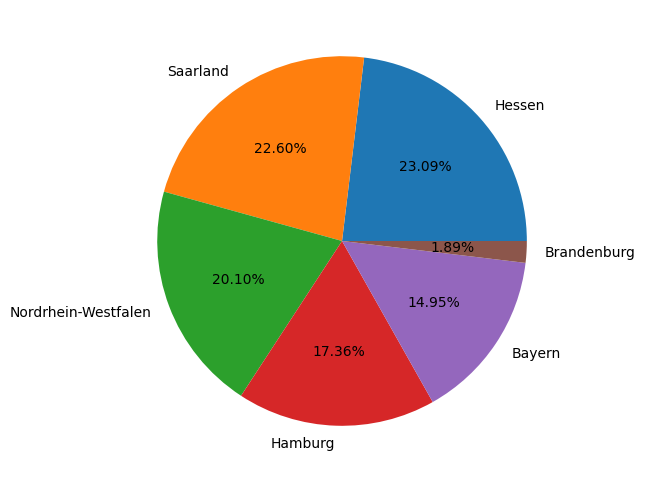

In [143]:
germany_revenue.plot(kind='pie', figsize=(6,6), autopct="%1.2f%%")

Percentage of Product Category sales in Germany 

In [149]:
germany_product_revenue = df.loc[(df["Country"] == "Germany")].groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)
germany_product_revenue
                                 

Product_Category
Bikes          6792782
Accessories    1548818
Clothing        636996
Name: Revenue, dtype: int64

<Axes: >

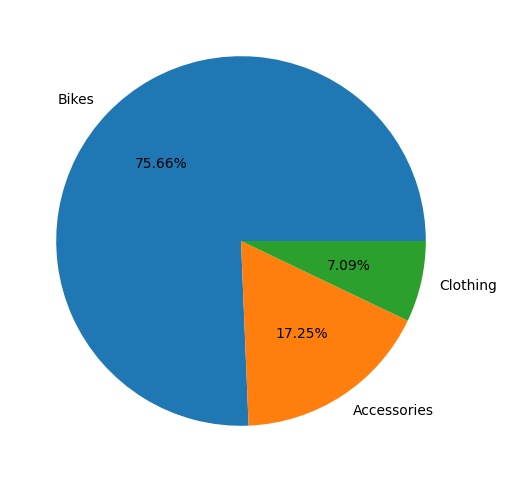

In [151]:
germany_product_revenue.plot(kind="pie", figsize=(6,6), autopct="%1.2f%%")

Products sales by countries

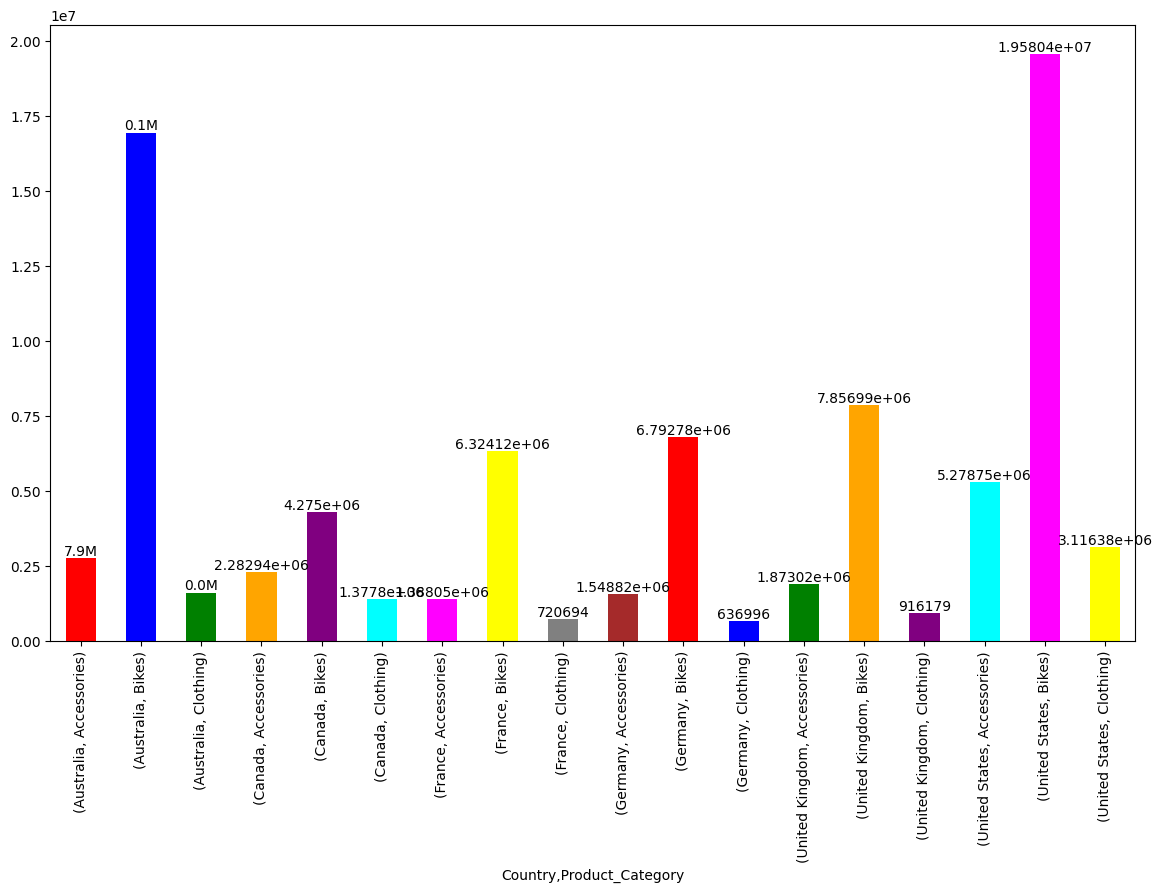

In [170]:
colors = [
    "red", "blue", "green", "orange", "purple",
    "cyan", "magenta", "yellow", "gray", "brown"
]

ax = (df.groupby(["Country", "Product_Category"])["Revenue"]
      .sum().
      plot(
            kind="bar", 
            figsize=(14, 8),
            color=colors
            ) 
            
    )

for i in ax.containers:
    ax.bar_label(i,
                 
                labels=[f'{v/1_000_000:.1f}M' for v in container.datavalues],
                
                 
            )
